# Módulo 3 — Baseline supervisado con TF-IDF

**Objetivo:** establecer el punto de referencia clásico del proyecto — TF-IDF +
clasificador supervisado sobre el corpus preprocesado en el Módulo 2. Las métricas
de este notebook son la **columna A** de la tabla comparativa del Módulo 4.

**Protocolo anti-leakage:** la selección de configuración se hace contra el split de
validación (10% del train, estratificado); el test set se evalúa **una sola vez**, con
la configuración ya elegida. `fit_transform` siempre sobre train; `transform` sobre
validación/test.

In [1]:
import sys
import time
import json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

from src.config import SEED, PROCESSED_DIR, METRICS_DIR
from src.dataset import train_val_split
from src.evaluate import report, save_metrics, plot_confusion

train_full = pd.read_csv(PROCESSED_DIR / "train_clean.csv")
test = pd.read_csv(PROCESSED_DIR / "test_clean.csv")
tr, val = train_val_split(train_full, val_size=0.1)
print(f"train: {len(tr):,} | val: {len(val):,} | test: {len(test):,}")

train: 7,200 | val: 800 | test: 2,000


## 1. Experimentación: tres configuraciones de TF-IDF

Se varían `max_features` y `ngram_range`; el resto de parámetros queda fijo
(`min_df=2`, `sublinear_tf=True`). El clasificador es Regresión Logística en las
tres corridas para aislar el efecto de la representación.

In [2]:
CONFIGS = {
    "A": {"max_features": 20_000, "ngram_range": (1, 1)},
    "B": {"max_features": 50_000, "ngram_range": (1, 2)},
    "C": {"max_features": 100_000, "ngram_range": (1, 2)},
}

resultados = {}
for name, params in CONFIGS.items():
    tfidf = TfidfVectorizer(min_df=2, sublinear_tf=True, **params)
    X_tr = tfidf.fit_transform(tr["text_clean"])
    X_val = tfidf.transform(val["text_clean"])
    clf = LogisticRegression(max_iter=1000, random_state=SEED)
    t0 = time.time()
    clf.fit(X_tr, tr["label"])
    t_fit = time.time() - t0
    f1_val = f1_score(val["label"], clf.predict(X_val), average="weighted")
    resultados[name] = {**params, "f1_val_weighted": round(f1_val, 4),
                        "fit_seconds": round(t_fit, 1)}
    print(f"config {name}: {params} -> F1 val {f1_val:.4f} ({t_fit:.0f}s)")

tabla = pd.DataFrame(resultados).T
tabla

config A: {'max_features': 20000, 'ngram_range': (1, 1)} -> F1 val 0.9046 (0s)


config B: {'max_features': 50000, 'ngram_range': (1, 2)} -> F1 val 0.9058 (0s)


config C: {'max_features': 100000, 'ngram_range': (1, 2)} -> F1 val 0.9058 (0s)


,max_features,ngram_range,f1_val_weighted,fit_seconds
A,20000,"(1, 1)",0.9046,0.1
B,50000,"(1, 2)",0.9058,0.2
C,100000,"(1, 2)",0.9058,0.2


## 2. Modelo final: mejor configuración, reentrenado sobre todo el train

**Justificación del clasificador:** Regresión Logística maneja bien matrices dispersas
de alta dimensión, entrena en segundos, expone probabilidades calibrables y sus
coeficientes son interpretables por clase — el baseline honesto contra el que medir
al Transformer. Naive Bayes es más rápido pero asume independencia entre features
(falsa con bi-gramas superpuestos); SVM lineal rinde parecido con más costo de ajuste.

In [3]:
best_name = max(resultados, key=lambda k: resultados[k]["f1_val_weighted"])
best_params = CONFIGS[best_name]
print(f"mejor configuración en validación: {best_name} -> {best_params}")

tfidf = TfidfVectorizer(min_df=2, sublinear_tf=True, **best_params)
X_train = tfidf.fit_transform(train_full["text_clean"])   # fit SOLO en train
X_test = tfidf.transform(test["text_clean"])

clf = LogisticRegression(max_iter=1000, random_state=SEED)
t0 = time.time()
clf.fit(X_train, train_full["label"])
train_seconds = time.time() - t0
print(f"entrenamiento final: {train_seconds:.0f}s | features: {X_train.shape[1]:,}")

mejor configuración en validación: B -> {'max_features': 50000, 'ngram_range': (1, 2)}


entrenamiento final: 0s | features: 25,507


## 3. Evaluación única sobre el test set

              precision    recall  f1-score   support

       World     0.9134    0.8860    0.8995       500
      Sports     0.9450    0.9620    0.9534       500
    Business     0.8480    0.8700    0.8588       500
    Sci_Tech     0.8763    0.8640    0.8701       500

    accuracy                         0.8955      2000
   macro avg     0.8957    0.8955    0.8955      2000
weighted avg     0.8957    0.8955    0.8955      2000

          World  Sports  Business  Sci_Tech
World       443      13        26        18
Sports        7     481         7         5
Business     21       6       435        38
Sci_Tech     14       9        45       432


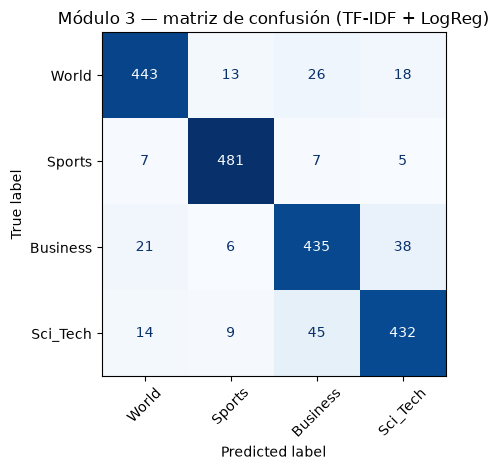

parámetros del modelo: 102,032


In [4]:
y_pred = clf.predict(X_test)
rep = report(test["label"], y_pred)

from sklearn.metrics import confusion_matrix
from src.config import LABEL_NAMES
cm = pd.DataFrame(confusion_matrix(test["label"], y_pred),
                  index=LABEL_NAMES, columns=LABEL_NAMES)
print(cm)
plot_confusion(test["label"], y_pred, "m3_confusion",
               "Módulo 3 — matriz de confusión (TF-IDF + LogReg)")

n_params = clf.coef_.size + clf.intercept_.size
save_metrics(rep, "baseline_tfidf", extra={
    "modelo": "TfidfVectorizer + LogisticRegression",
    "configuracion": {**best_params, "min_df": 2, "sublinear_tf": True},
    "experimentos_validacion": resultados,
    "parametros_entrenables": n_params,
    "tiempo_entrenamiento_seg": round(train_seconds, 1),
})
print(f"parámetros del modelo: {n_params:,}")

## 4. Análisis: qué configuración ganó y qué categorías cuestan más

**Selección:** la configuración **B** ganó en validación por un margen mínimo (F1 0.9058
vs. 0.9046 de la A): con el texto ya limpio, los bigramas aportan una señal marginal pero
real. C empata exactamente con B porque el vocabulario efectivo con `min_df=2` (22.851
features en el split de experimentación) no llega al tope de 50.000 — subir `max_features`
a 100.000 no agrega nada. El modelo final (B sobre todo el train) usa **25.507 features y
102.032 parámetros**, y entrena en **0.2 s**.

**En test: accuracy 0.8955, F1 weighted 0.8955** — en línea con el baseline de referencia
de la cátedra (F1 macro ≈ 0.90). Las categorías difíciles según la matriz de confusión:

- **Business ↔ Sci_Tech** concentra el mayor cruce (38 + 45 = 83 errores): las noticias
  de resultados de empresas tecnológicas comparten léxico con las de producto
  ("microsoft", "company", "stock") y un modelo de bolsa de palabras no distingue *de qué
  habla* la noticia, solo *con qué palabras*.
- **World ↔ Business** es el segundo cruce (26 + 21 = 47): macroeconomía y geopolítica se
  solapan ("oil", "price", "iraq").
- **Sports** es casi limpia (F1 0.9534): su vocabulario es el más exclusivo del corpus.

Este es el techo natural del enfoque léxico: los errores restantes requieren entender
contexto y semántica de secuencia, exactamente lo que el Transformer del Módulo 4 debería
capturar.